In [5]:
import subprocess, sys
from pathlib import Path

def mp4_to_wav(mp4_path, wav_path=None, sample_rate=44100, mono=False):
    src = Path(mp4_path)
    dst = Path(wav_path) if wav_path else src.with_suffix(".wav")
    cmd = ["ffmpeg", "-y", "-i", str(src), "-vn", "-acodec", "pcm_s16le", "-ar", str(sample_rate)]
    if mono:
        cmd += ["-ac", "1"]
    subprocess.run(cmd + [str(dst)], check=True)
    return dst

mp4_to_wav("20260701-111_Canon_700D.mp4", wav_path="test_wav.wav")

WindowsPath('test_wav.wav')

Text(0, 0.5, 'RPM')

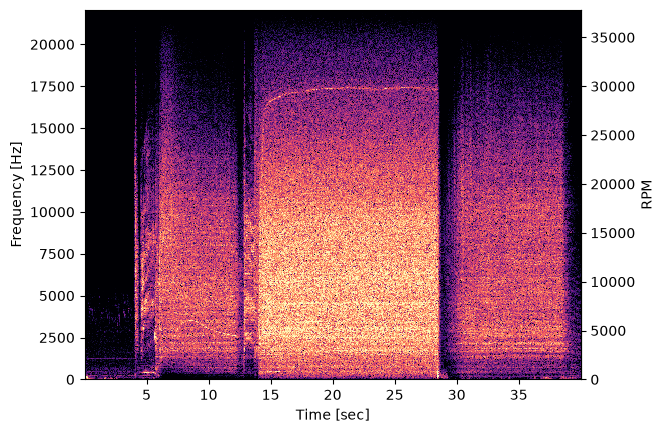

In [13]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy import interpolate


WAV, BLADES = "test_wav.wav", 35
N, H = 4096, 2048          # window, hop
JUMP_HZ, MIN_DB = 400, 8   # max ridge move per frame, tone-lost threshold

# load
fs, x = wavfile.read(WAV)
x = x.astype(float)
if x.ndim > 1: x = x[:, 0]      # keep left channel only
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(x = x, fs = fs, nfft=N, nperseg=N)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(t, f, 10 * np.log10(Sxx), cmap="magma", vmin=0, vmax=40)
# fig.colorbar(pcm, ax=ax, label="Power [dB]", pad=0.12)
ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel("Time [sec]")

sec = ax.secondary_yaxis("right", functions=(lambda hz: 60 * hz / BLADES,
                                             lambda rpm: rpm * BLADES / 60))
sec.set_ylabel("RPM")